In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 1.LOADING DATA

In [2]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

In [3]:
df_test_id = pd.DataFrame(df_test['id'])

In [4]:
df_train.drop('id',axis=1,inplace=True)
df_test.drop('id',axis=1,inplace=True)

In [5]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   annual_income         593994 non-null  float64
 1   debt_to_income_ratio  593994 non-null  float64
 2   credit_score          593994 non-null  int64  
 3   loan_amount           593994 non-null  float64
 4   interest_rate         593994 non-null  float64
 5   gender                593994 non-null  str    
 6   marital_status        593994 non-null  str    
 7   education_level       593994 non-null  str    
 8   employment_status     593994 non-null  str    
 9   loan_purpose          593994 non-null  str    
 10  grade_subgrade        593994 non-null  str    
 11  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(1), str(6)
memory usage: 54.4 MB


## 2.EDA

In [6]:
import math
def plot_all_pie(df,title_prefix=""):
    pie_cols = [col for col in df_train.columns if df_train[col].nunique() <=10]

    n_cols = 3
    n_rows = math.ceil(len(pie_cols) / n_cols)

    plt.figure(figsize=(5*n_cols,5*n_rows))

    for i , col in enumerate(pie_cols,1):
        plt.subplot(n_rows,n_cols,i)
        data = df_train[col].value_counts()

        plt.pie(data,
            labels=data.index,
            autopct = "%1.1f%%",
            startangle=140,
            colors = sns.color_palette('Set3'),
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
        plt.title(f"{title_prefix} {col} Distribution",fontsize=12,fontweight='bold')

    plt.tight_layout()
    plt.show()


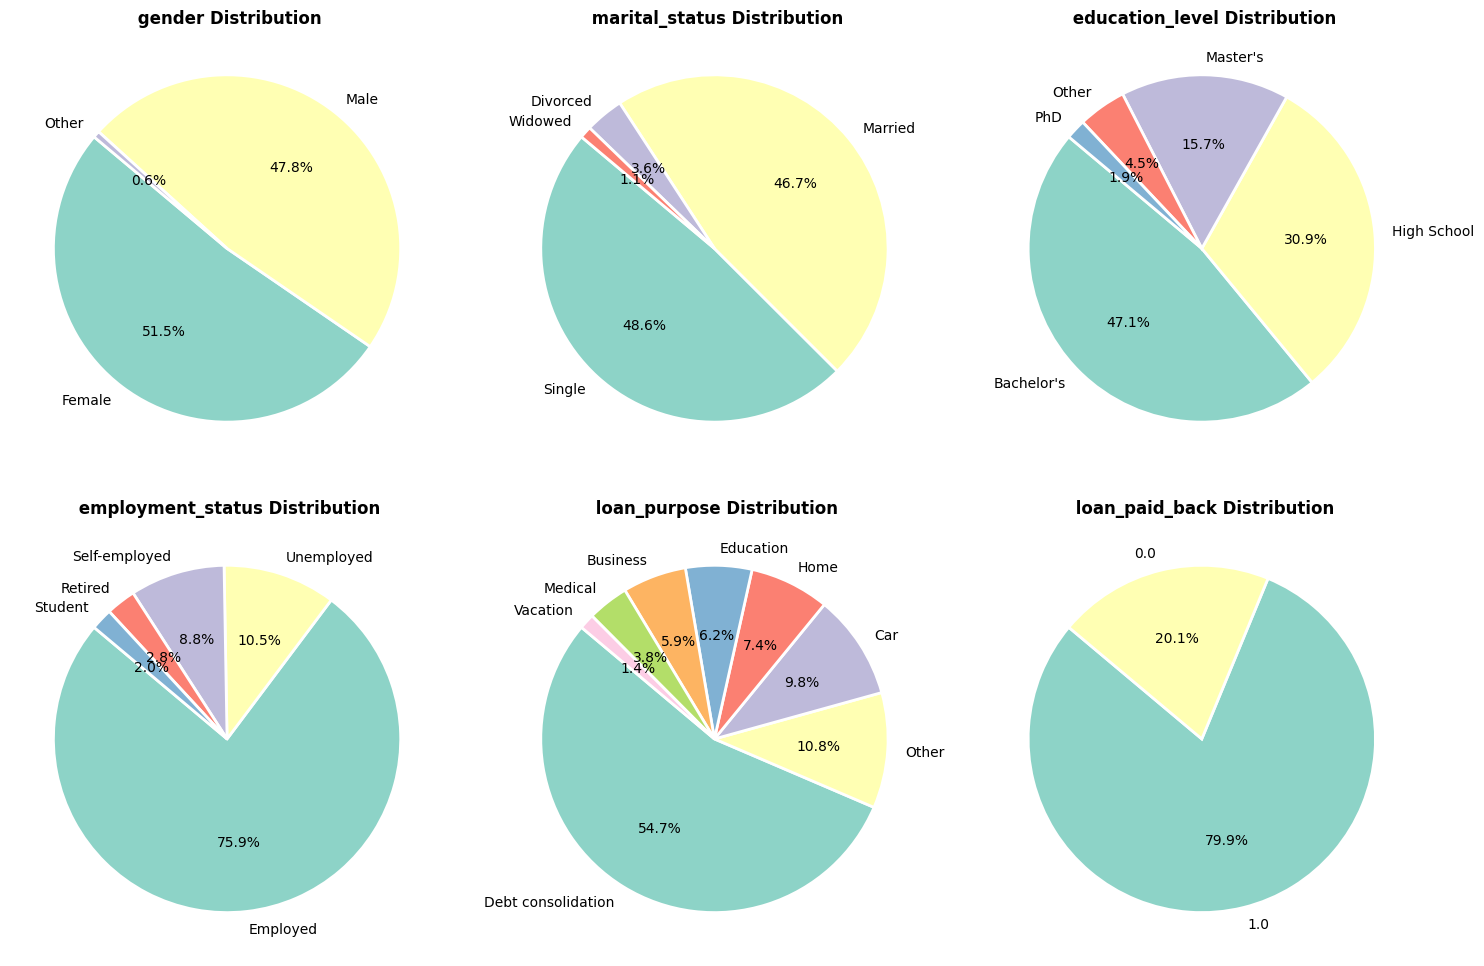

In [7]:
plot_all_pie(df_train)

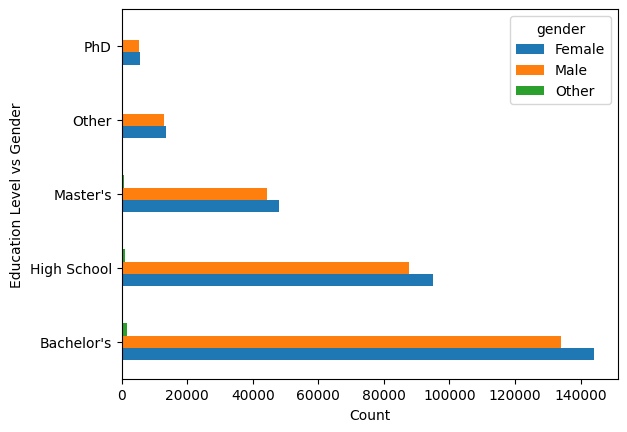

In [8]:
edc_level_gender = df_train.groupby(['education_level','gender']).size().unstack()
edc_level_gender.plot(kind='barh')
plt.xlabel('Count')
plt.ylabel('Education Level vs Gender')

plt.show()

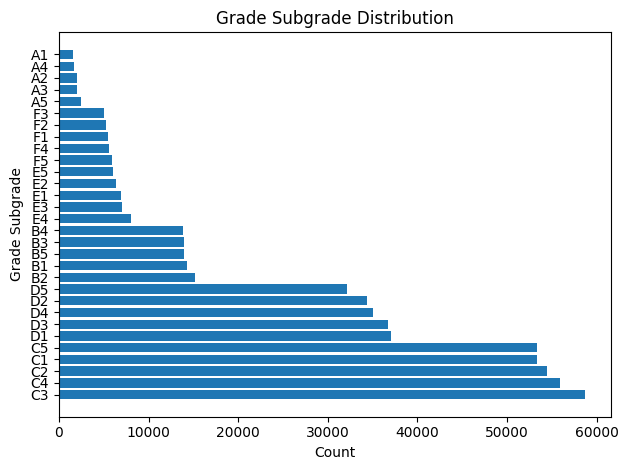

In [9]:
grd_counts = df_train['grade_subgrade'].value_counts()
plt.barh(grd_counts.index,grd_counts.values)
plt.xlabel("Count")
plt.ylabel("Grade Subgrade")
plt.title("Grade Subgrade Distribution")
plt.tight_layout()
plt.show()

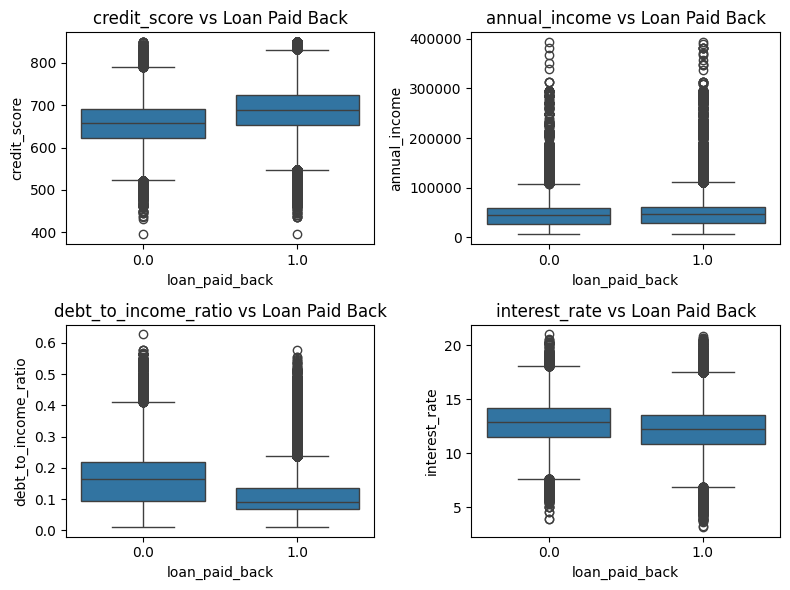

In [10]:
colss = ['credit_score', 'annual_income', 'debt_to_income_ratio', 'interest_rate']
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
for ax, col in zip(axes.flatten(), colss):
    sns.boxplot(data=df_train, x='loan_paid_back', y=col, ax=ax)
    ax.set_title(f'{col} vs Loan Paid Back')
plt.tight_layout()
plt.show()

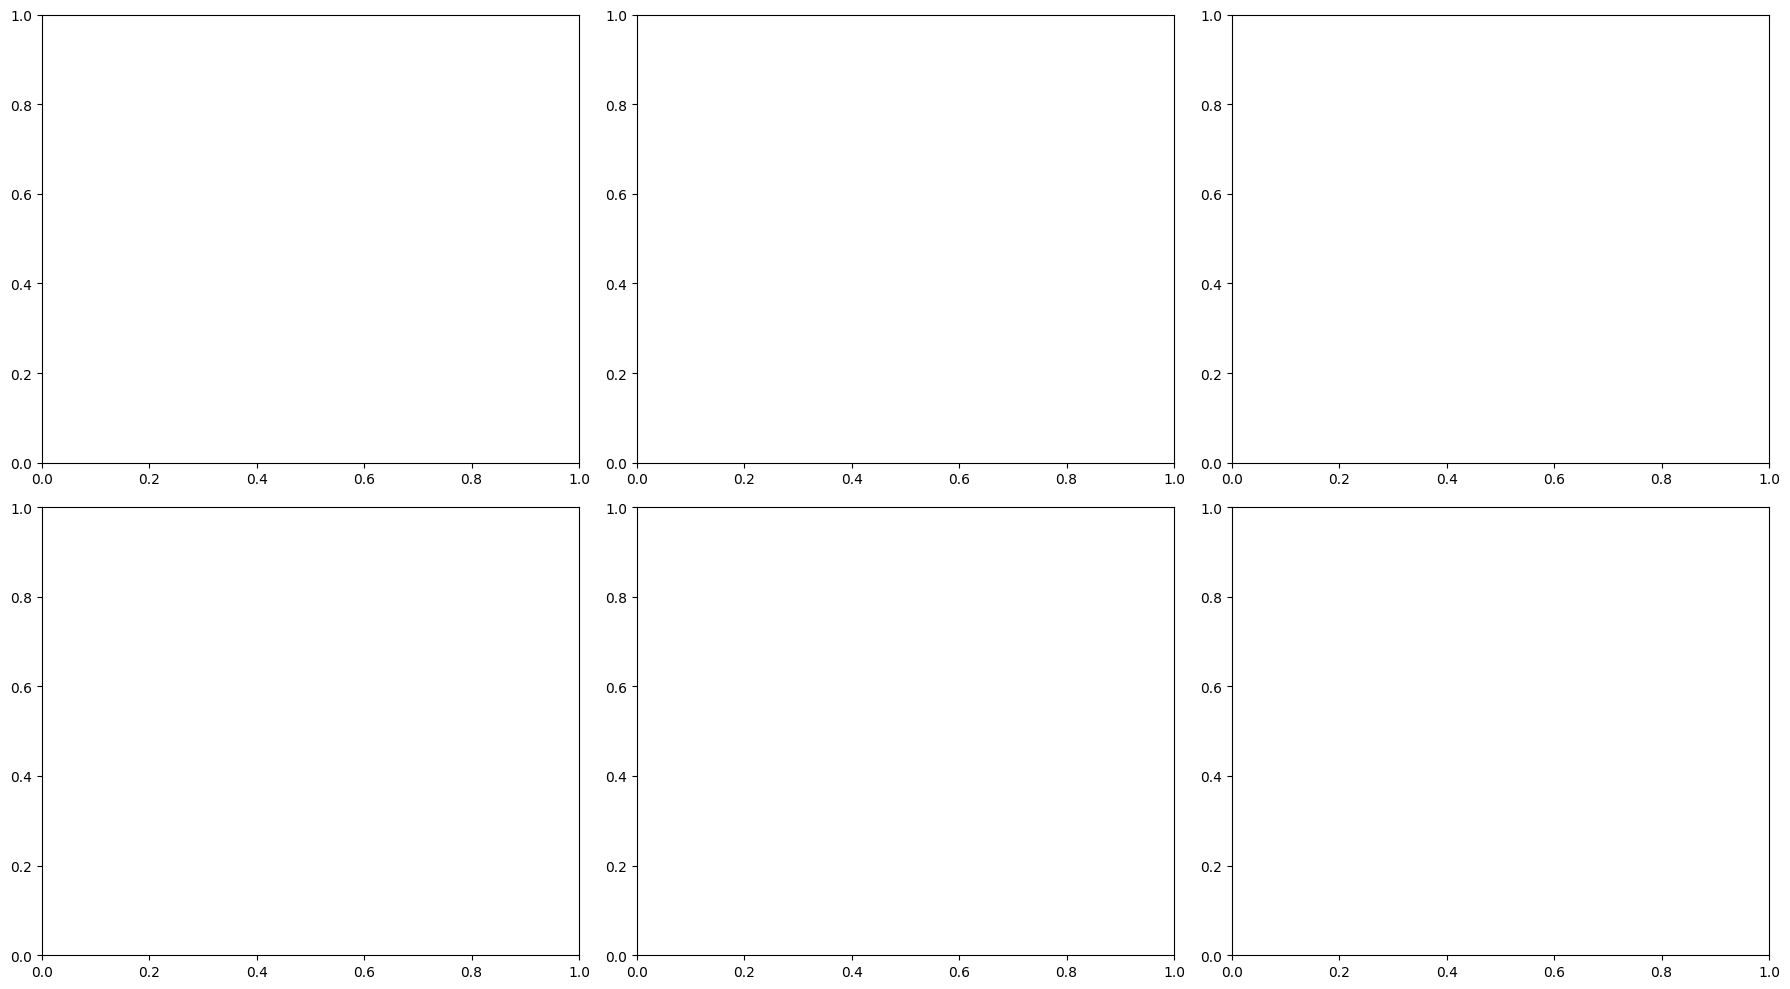

In [11]:
fig, axes = plt.subplots(2,3,figsize=(18,10))

cat_cols = [col for col in df_train.columns if df_train[col].dtype=="O"]
for ax, col in zip(axes.flatten(),cat_cols):
    df_train.groupby(col)['loan_paid_back'].mean().sort_values().plot(kind='barh',ax=ax)
    ax.set_title(f"Loan Paid Back Rate : {col}")
    ax.set_xlabel('Pay Rate')

plt.tight_layout()
plt.show()

In [12]:
numeric_cols = [col for col in df_train.columns if df_train[col].dtype!="O"]


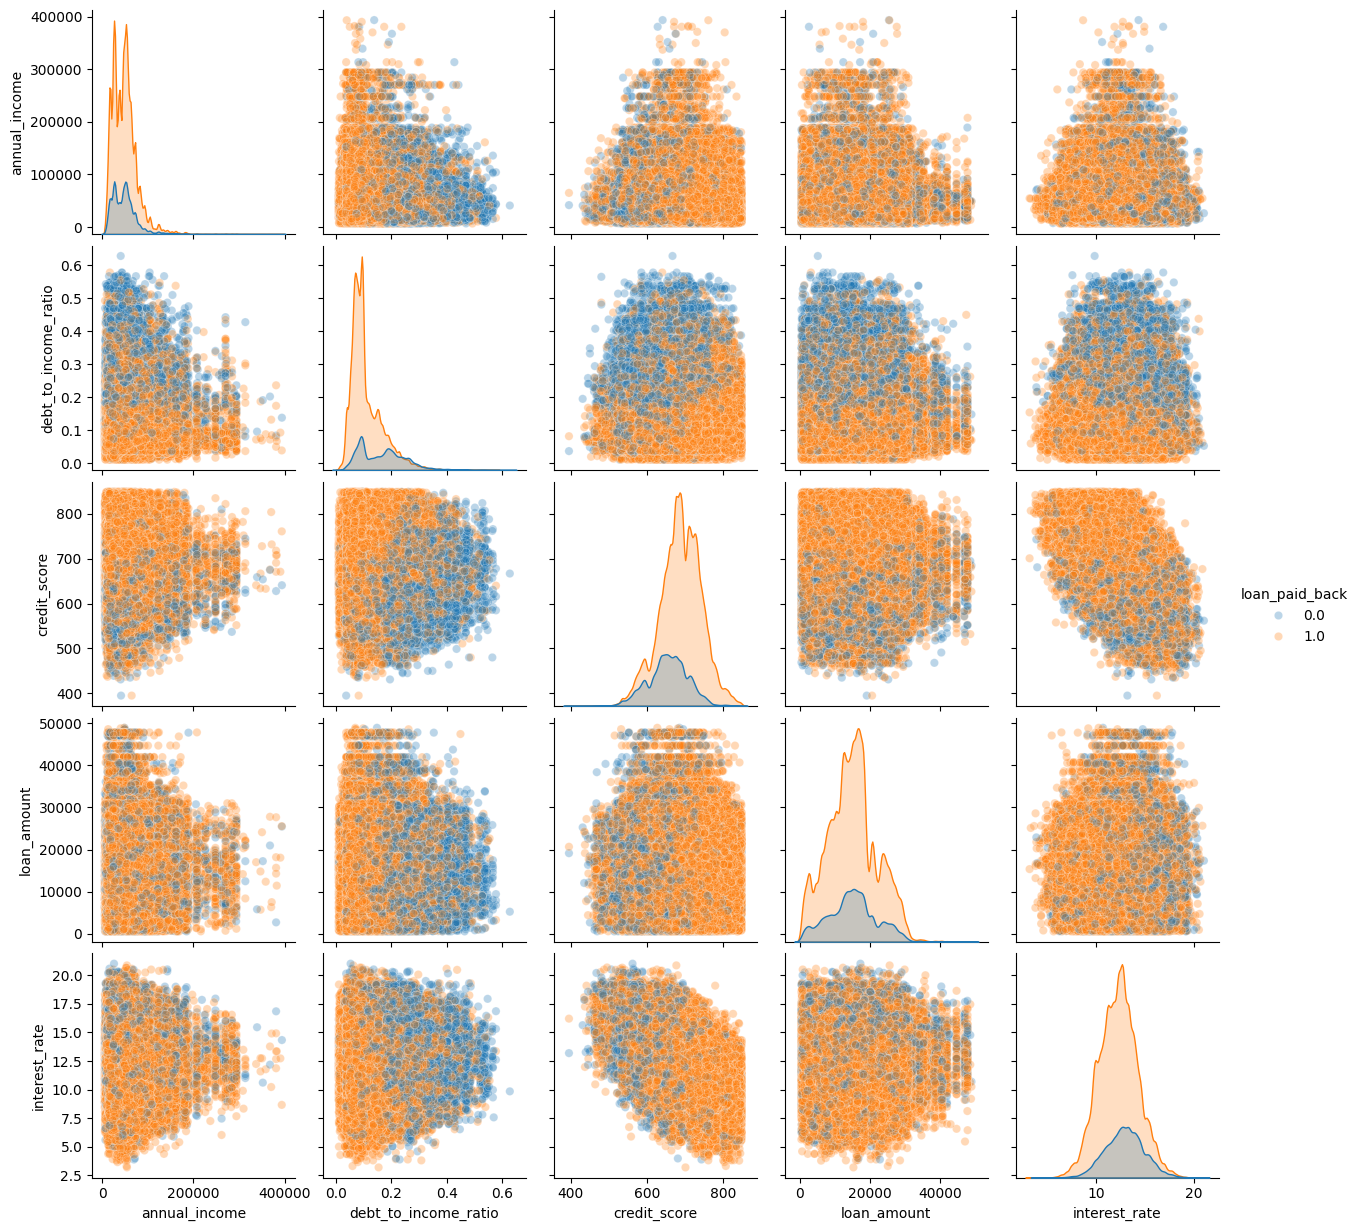

In [13]:
sns.pairplot(df_train[numeric_cols],hue='loan_paid_back',diag_kind='kde',plot_kws={'alpha':0.3})

In [14]:
def plot_all_hist(df_train,title_prefix = ""):
    num_cols = df_train.select_dtypes(include=["int64","float"]).columns
    n_cols=3
    n_rows = math.ceil(len(numeric_cols)/n_cols)
    plt.figure(figsize=(5*n_cols,5*n_rows))
    for i, col in enumerate(numeric_cols,1):
        plt.subplot(n_rows,n_cols,i)
        sns.histplot(df_train[col],kde=True,bins=40,)
        plt.title(f"{title_prefix} {col}")

    plt.tight_layout()
    plt.show()


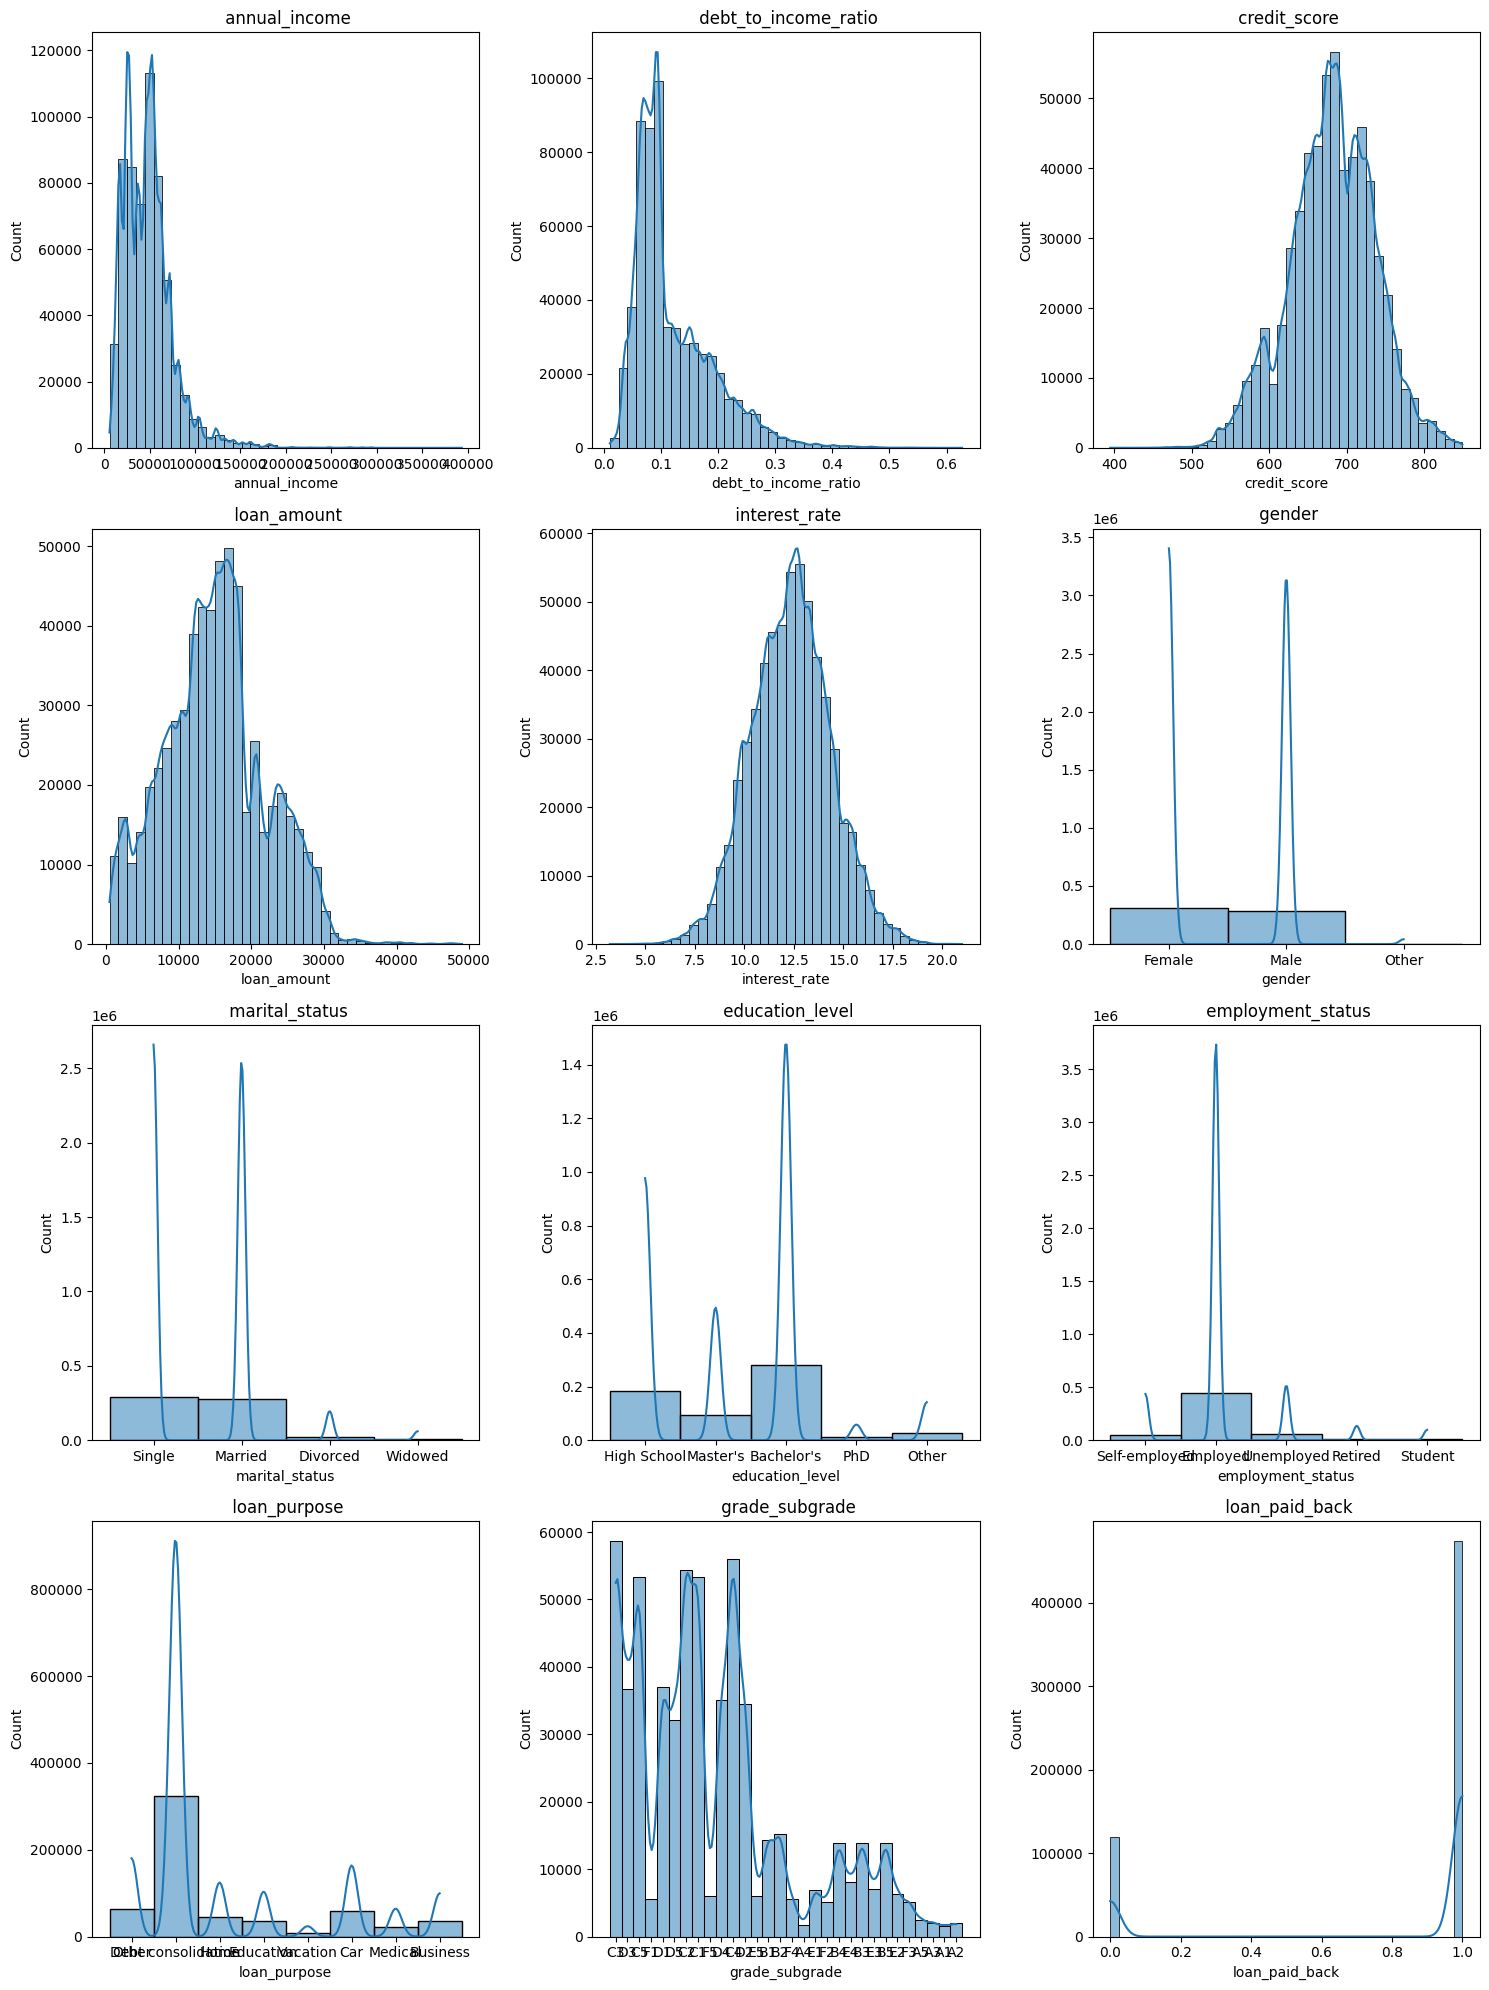

In [15]:
plot_all_hist(df_train)

In [16]:
def show_value_counts(df, cols):
    for col in cols:
        print(f"\n{col}")
        print('------------------')
        print(df[col].value_counts()
             )

In [17]:
show_value_counts(df_train,cat_cols)

## 3.FEATURE ENGINEERING

In [18]:
cols_to_onehot = ['gender','marital_status','employment_status']

In [19]:
df_train = pd.get_dummies(df_train,columns=cols_to_onehot,drop_first=True,dtype=int)
df_test = pd.get_dummies(df_test,columns=cols_to_onehot,drop_first=True,dtype=int)

In [20]:
df_train['education_level'].value_counts()

education_level
Bachelor's     279606
High School    183592
Master's        93097
Other           26677
PhD             11022
Name: count, dtype: int64

In [21]:
education_order = {
    'Other':0,
    'High School':1,
    'Bachelor\'s': 2,
    'Master\'s': 3,
    'PhD': 4
}

df_train['education_level'] = df_train['education_level'].map(education_order)
df_test['education_level'] = df_test['education_level'].map(education_order)

In [22]:
grade_order = sorted(df_train['grade_subgrade'].unique(),
                     key=lambda x: (x[0], int(x[1])))
grade_mapping = {grade: idx for idx, grade in enumerate(grade_order)}
df_train['grade_subgrade'] = df_train['grade_subgrade'].map(grade_mapping)


grade_order = sorted(df_test['grade_subgrade'].unique(),
                     key=lambda x: (x[0], int(x[1])))
grade_mapping = {grade: idx for idx, grade in enumerate(grade_order)}
df_test['grade_subgrade'] = df_test['grade_subgrade'].map(grade_mapping)

In [23]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 254569 entries, 0 to 254568
Data columns (total 17 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   annual_income                    254569 non-null  float64
 1   debt_to_income_ratio             254569 non-null  float64
 2   credit_score                     254569 non-null  int64  
 3   loan_amount                      254569 non-null  float64
 4   interest_rate                    254569 non-null  float64
 5   education_level                  254569 non-null  int64  
 6   loan_purpose                     254569 non-null  str    
 7   grade_subgrade                   254569 non-null  int64  
 8   gender_Male                      254569 non-null  int64  
 9   gender_Other                     254569 non-null  int64  
 10  marital_status_Married           254569 non-null  int64  
 11  marital_status_Single            254569 non-null  int64  
 12  marital_statu

In [24]:
freq_map_tr = df_train['loan_purpose'].value_counts(normalize=True)
freq_map_test = df_test['loan_purpose'].value_counts(normalize=True)

In [25]:
df_train['loan_purpose'] = df_train['loan_purpose'].map(freq_map_tr)
df_test['loan_purpose'] = df_test['loan_purpose'].map(freq_map_test)

In [26]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 18 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   annual_income                    593994 non-null  float64
 1   debt_to_income_ratio             593994 non-null  float64
 2   credit_score                     593994 non-null  int64  
 3   loan_amount                      593994 non-null  float64
 4   interest_rate                    593994 non-null  float64
 5   education_level                  593994 non-null  int64  
 6   loan_purpose                     593994 non-null  float64
 7   grade_subgrade                   593994 non-null  int64  
 8   loan_paid_back                   593994 non-null  float64
 9   gender_Male                      593994 non-null  int64  
 10  gender_Other                     593994 non-null  int64  
 11  marital_status_Married           593994 non-null  int64  
 12  marital_statu

In [27]:
df_train['loan_to_income'] = df_train['loan_amount'] / (df_train['annual_income'] + 1)
df_test['loan_to_income']  = df_test['loan_amount'] / (df_test['annual_income'] + 1)


In [28]:
df_train['risk_score'] = df_train['debt_to_income_ratio'] * df_train['interest_rate']
df_test['risk_score']  = df_test['debt_to_income_ratio'] * df_test['interest_rate']

In [29]:
df_train['log_income'] = np.log1p(df_train['annual_income'])
df_test['log_income']  = np.log1p(df_test['annual_income'])


In [30]:
df_train['grade_main'] = df_train['grade_subgrade'] // 5
df_test['grade_main']  = df_test['grade_subgrade'] // 5

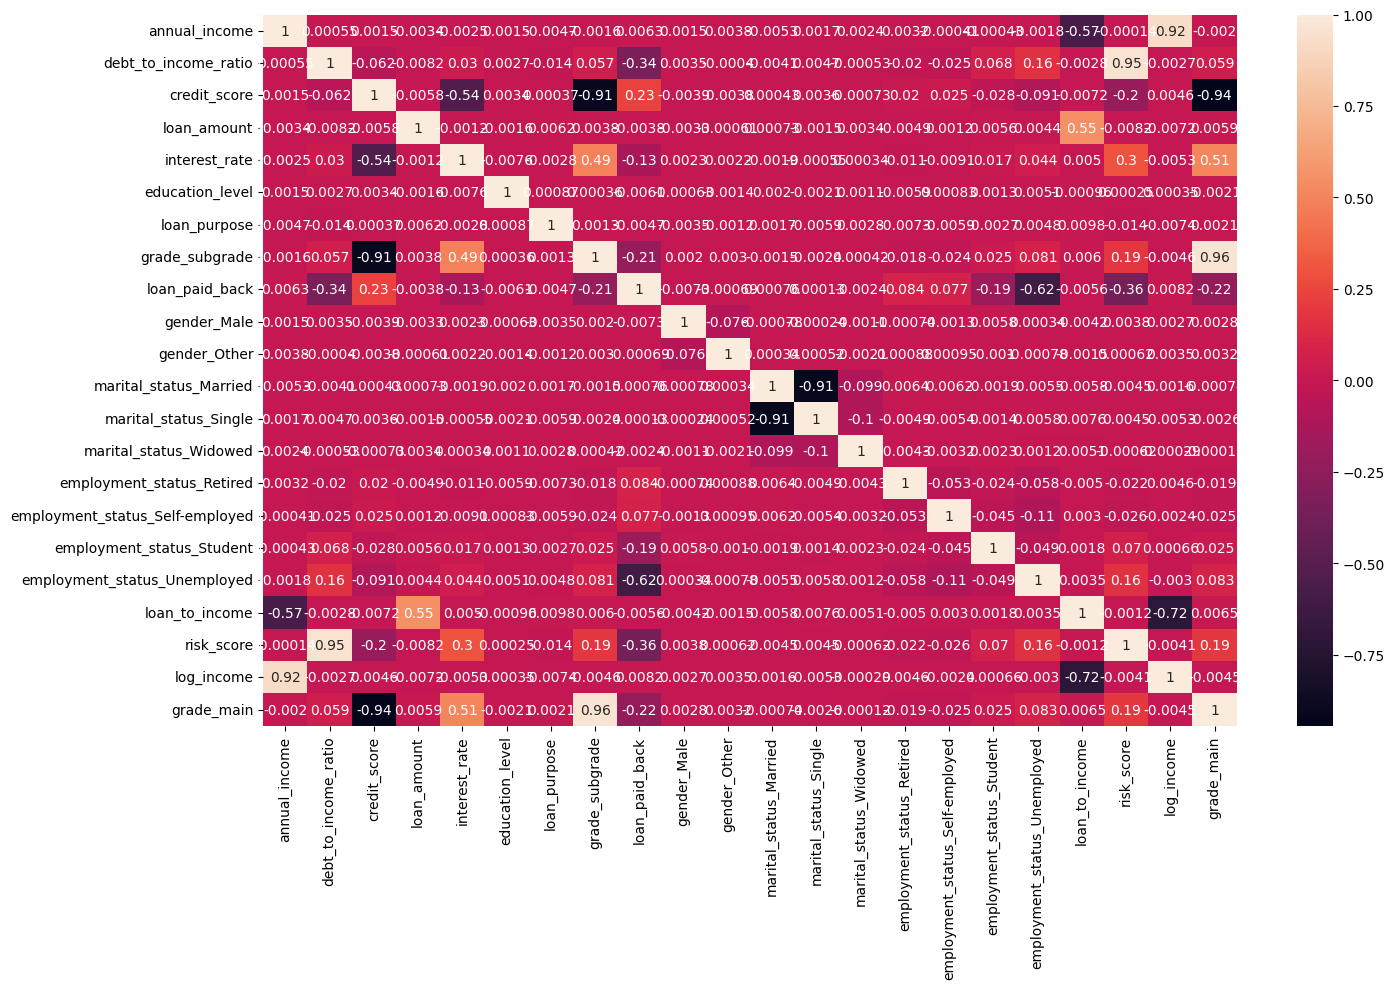

In [31]:
plt.figure(figsize=(15,10))
sns.heatmap(df_train.corr(),annot=True)
plt.tight_layout()
plt.show()

## 4.FEATURE IMPORTANCES

In [32]:
corr = df_train.corr(numeric_only=True)

target_corr = corr['loan_paid_back'].sort_values(ascending=False)

print(target_corr)

loan_paid_back                     1.000000
credit_score                       0.234560
employment_status_Retired          0.083526
employment_status_Self-employed    0.077374
log_income                         0.008248
annual_income                      0.006326
marital_status_Married             0.000758
marital_status_Single              0.000131
gender_Other                      -0.000691
marital_status_Widowed            -0.002372
loan_amount                       -0.003762
loan_purpose                      -0.004706
loan_to_income                    -0.005611
education_level                   -0.006080
gender_Male                       -0.007326
interest_rate                     -0.131184
employment_status_Student         -0.191178
grade_subgrade                    -0.212376
grade_main                        -0.218781
debt_to_income_ratio              -0.335680
risk_score                        -0.355044
employment_status_Unemployed      -0.616839
Name: loan_paid_back, dtype: flo

In [33]:
X = df_train.drop('loan_paid_back',axis=1)
y = df_train['loan_paid_back']

## 5.TRAINING MODELS

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.3,
    random_state=42
)

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [37]:
!pip install catboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


models_classification = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Extra Trees': ExtraTreesClassifier(),

    'KNN Classifier': KNeighborsClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),

    'XGBoost': XGBClassifier(),
    'LightGBM': LGBMClassifier(),
    'CatBoost': CatBoostClassifier()

}

In [39]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score
def evaluate_scores(true,predicted):
    accuracy = accuracy_score(true,predicted)
    report  = classification_report(true,predicted)
    matrix = confusion_matrix(true,predicted)
    roc = roc_auc_score(true,predicted)


    return accuracy,report,matrix,roc


In [40]:
for i in range(len(list(models_classification))):
    model = list(models_classification.values())[i]
    model.fit(X_train_scaled,y_train)
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_accuracy,train_report,train_matrix,train_roc = evaluate_scores(y_train,y_train_pred)
    test_accuracy,test_report,test_matrix,test_roc = evaluate_scores(y_test,y_test_pred)

    print(list(models_classification.keys())[i])
    print('model performance for Training Set')
    print('Root accuracy: ',train_accuracy)
    print(train_report)
    print(train_matrix)
    print('Root roc: ',train_roc)

    print('-------------------------------')
    print('model performance for Test Set')
    print('Test accuracy: ',test_accuracy)
    print(test_report)
    print(test_matrix)
    print('Test Roc: ',test_roc)

    print('******************************')
    print('******************************')

Logistic Regression
model performance for Training Set
Root accuracy:  0.8998232301975734
              precision    recall  f1-score   support

         0.0       0.85      0.61      0.71     83403
         1.0       0.91      0.97      0.94    332392

    accuracy                           0.90    415795
   macro avg       0.88      0.79      0.82    415795
weighted avg       0.90      0.90      0.89    415795

[[ 50536  32867]
 [  8786 323606]]
Root roc:  0.7897464002675774
-------------------------------
model performance for Test Set
Test accuracy:  0.8995841727506888
              precision    recall  f1-score   support

         0.0       0.86      0.61      0.71     36097
         1.0       0.91      0.97      0.94    142102

    accuracy                           0.90    178199
   macro avg       0.88      0.79      0.82    178199
weighted avg       0.90      0.90      0.89    178199

[[ 21861  14236]
 [  3658 138444]]
Test Roc:  0.7899380614110803
****************************

/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM
model performance for Training Set
Root accuracy:  0.9056025204728292
              precision    recall  f1-score   support

         0.0       0.90      0.60      0.72     83403
         1.0       0.91      0.98      0.94    332392

    accuracy                           0.91    415795
   macro avg       0.90      0.79      0.83    415795
weighted avg       0.90      0.91      0.90    415795

[[ 49991  33412]
 [  5838 326554]]
Root roc:  0.7909136547973117
-------------------------------
model performance for Test Set
Test accuracy:  0.903719998428723
              precision    recall  f1-score   support

         0.0       0.89      0.60      0.71     36097
         1.0       0.91      0.98      0.94    142102

    accuracy                           0.90    178199
   macro avg       0.90      0.79      0.83    178199
weighted avg       0.90      0.90      0.90    178199

[[ 21502  14595]
 [  2562 139540]]
Test Roc:  0.7888217338476251
******************************
*********

In [41]:
cols_to_drop = [
    "marital_status_Married", "marital_status_Single", "marital_status_Widowed",
    "gender_Other", "gender_Male", "loan_purpose", "education_level",
    "annual_income", "log_income", "loan_amount", "loan_to_income"
]

In [42]:
X.drop(cols_to_drop,axis=1,inplace=True)

In [43]:
X

,debt_to_income_ratio,credit_score,interest_rate,grade_subgrade,employment_status_Retired,employment_status_Self-employed,employment_status_Student,employment_status_Unemployed,risk_score,grade_main
0,0.084,736,13.67,12,0,1,0,0,1.14828,2
1,0.166,636,12.92,17,0,0,0,0,2.14472,3
2,0.097,694,9.76,14,0,0,0,0,0.94672,2
3,0.065,533,16.10,25,0,0,0,0,1.04650,5
4,0.053,665,10.21,15,0,0,0,0,0.54113,3
...,...,...,...,...,...,...,...,...,...,...
593989,0.152,703,10.92,12,0,0,0,0,1.65984,2
593990,0.105,559,14.62,29,0,0,0,0,1.53510,5
593991,0.072,675,14.13,10,0,0,0,0,1.01736,2
593992,0.067,740,9.87,6,0,0,0,0,0.66129,1


In [44]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.3,
    random_state=42
)

In [45]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


models_classification = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Extra Trees': ExtraTreesClassifier(),

    'KNN Classifier': KNeighborsClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),

    'XGBoost': XGBClassifier(),
    'LightGBM': LGBMClassifier(verbose=0),
    'CatBoost': CatBoostClassifier(verbose=0)

}

In [47]:
for i in range(len(list(models_classification))):
    model = list(models_classification.values())[i]
    model.fit(X_train_scaled,y_train)
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_accuracy,train_report,train_matrix,train_roc = evaluate_scores(y_train,y_train_pred)
    test_accuracy,test_report,test_matrix,test_roc = evaluate_scores(y_test,y_test_pred)

    print(list(models_classification.keys())[i])
    print('model performance for Training Set')
    print('Root accuracy: ',train_accuracy)
    print(train_report)
    print(train_matrix)
    print('Root roc: ',train_roc)

    print('-------------------------------')
    print('model performance for Test Set')
    print('Test accuracy: ',test_accuracy)
    print(test_report)
    print(test_matrix)
    print('Test Roc: ',test_roc)

    print('******************************')
    print('******************************')

Logistic Regression
model performance for Training Set
Root accuracy:  0.8998328503228754
              precision    recall  f1-score   support

         0.0       0.85      0.61      0.71     83403
         1.0       0.91      0.97      0.94    332392

    accuracy                           0.90    415795
   macro avg       0.88      0.79      0.82    415795
weighted avg       0.90      0.90      0.89    415795

[[ 50526  32877]
 [  8772 323620]]
Root roc:  0.7897075098576275
-------------------------------
model performance for Test Set
Test accuracy:  0.8996459014921521
              precision    recall  f1-score   support

         0.0       0.86      0.61      0.71     36097
         1.0       0.91      0.97      0.94    142102

    accuracy                           0.90    178199
   macro avg       0.88      0.79      0.82    178199
weighted avg       0.90      0.90      0.89    178199

[[ 21875  14222]
 [  3661 138441]]
Test Roc:  0.7901214275457029
****************************

/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM
model performance for Training Set
Root accuracy:  0.9053475871523227
              precision    recall  f1-score   support

         0.0       0.89      0.60      0.72     83403
         1.0       0.91      0.98      0.94    332392

    accuracy                           0.91    415795
   macro avg       0.90      0.79      0.83    415795
weighted avg       0.90      0.91      0.90    415795

[[ 50077  33326]
 [  6030 326362]]
Root roc:  0.7911404081663433
-------------------------------
model performance for Test Set
Test accuracy:  0.9039500782832676
              precision    recall  f1-score   support

         0.0       0.89      0.60      0.72     36097
         1.0       0.91      0.98      0.94    142102

    accuracy                           0.90    178199
   macro avg       0.90      0.79      0.83    178199
weighted avg       0.90      0.90      0.90    178199

[[ 21620  14477]
 [  2639 139463]]
Test Roc:  0.790185286560532
******************************
*********

## 6.HYPERPARAMETER TUNING WITH STRATIFIEDKFOLD

In [48]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import gc
cols_to_drop = [
    "marital_status_Married", "marital_status_Single", "marital_status_Widowed",
    "gender_Other", "gender_Male", "loan_purpose", "education_level",
    "annual_income", "log_income", "loan_amount", "loan_to_income"
]


X_test_final = df_test.drop(cols_to_drop, axis=1)

for df in [X, X_test_final]:
    df['risk_factor'] = df['interest_rate'] * (df['grade_subgrade'] + 1)
    df['credit_efficiency'] = df['credit_score'] / (df['interest_rate'] + 1)
    df['dti_grade'] = df['debt_to_income_ratio'] * (df['grade_main'] + 1)

lgbm_params = {
    'colsample_bytree': 0.619881270749716, 'learning_rate': 0.2555209060957825,
    'max_depth': 3, 'n_estimators': 800, 'num_leaves': 129,
    'reg_alpha': 3.1816630909294767, 'reg_lambda': 1.2523090930279208,
    'subsample': 0.7949354237802719, 'objective': 'binary', 'metric': 'auc',
    'random_state': 42, 'n_jobs': -1, 'verbose': -1
}

cat_params = {
    'iterations': 1000, 'learning_rate': 0.03, 'depth': 6,
    'l2_leaf_reg': 3, 'random_seed': 42, 'verbose': 0
}

n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test_final))


for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test_final)


    model_lgb = LGBMClassifier(**lgbm_params)
    model_cat = CatBoostClassifier(**cat_params)

    model_lgb.fit(X_train_s, y_train)
    model_cat.fit(X_train_s, y_train)


    lgb_val = model_lgb.predict_proba(X_val_s)[:, 1]
    cat_val = model_cat.predict_proba(X_val_s)[:, 1]

    lgb_test = model_lgb.predict_proba(X_test_s)[:, 1]
    cat_test = model_cat.predict_proba(X_test_s)[:, 1]


    fold_val_preds = np.sqrt((lgb_val**2 * 0.70) + (cat_val**2 * 0.30))
    fold_test_preds = np.sqrt((lgb_test**2 * 0.70) + (cat_test**2 * 0.30))

    oof_preds[val_idx] = fold_val_preds
    test_preds += fold_test_preds / n_splits

    print(f"Fold {fold} AUC: {roc_auc_score(y_val, fold_val_preds):.5f}")

    del model_lgb, model_cat; gc.collect()

overall_auc = roc_auc_score(y, oof_preds)
print(f"\n Final Optimized OOF AUC: {overall_auc:.6f}")

submission = pd.DataFrame({
    'id': df_test_id['id'],
    'loan_paid_back': test_preds
})
submission.to_csv('submission_0926_target.csv', index=False)

/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1 AUC: 0.92420


/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2 AUC: 0.92187


/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

Fold 8 AUC: 0.92297


/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 9 AUC: 0.92091


/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/brian/NYU/Responsible Data Science/Final Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 10 AUC: 0.92207

 Final Optimized OOF AUC: 0.922074


## 6.5 Baseline performance


In [120]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, roc_auc_score,
                             ConfusionMatrixDisplay)

y_true = y.values
y_pred = (oof_preds >= 0.5).astype(int)

print(pd.Series(y_true).value_counts(normalize=True))
print('accuracy', accuracy_score(y_true, y_pred))
print('precision', precision_score(y_true, y_pred))
print('recall', recall_score(y_true, y_pred))
print('f1', f1_score(y_true, y_pred))
print('auc', roc_auc_score(y_true, oof_preds))
print(classification_report(y_true, y_pred, target_names=['default', 'paid_back']))


1.0    0.79882
0.0    0.20118
Name: proportion, dtype: float64
accuracy 0.9058610019629828
precision 0.9092516112884049
recall 0.9799575969348401
f1 0.9432814747344014
auc 0.9220744913061583
              precision    recall  f1-score   support

     default       0.88      0.61      0.72    119500
   paid_back       0.91      0.98      0.94    474494

    accuracy                           0.91    593994
   macro avg       0.90      0.80      0.83    593994
weighted avg       0.90      0.91      0.90    593994



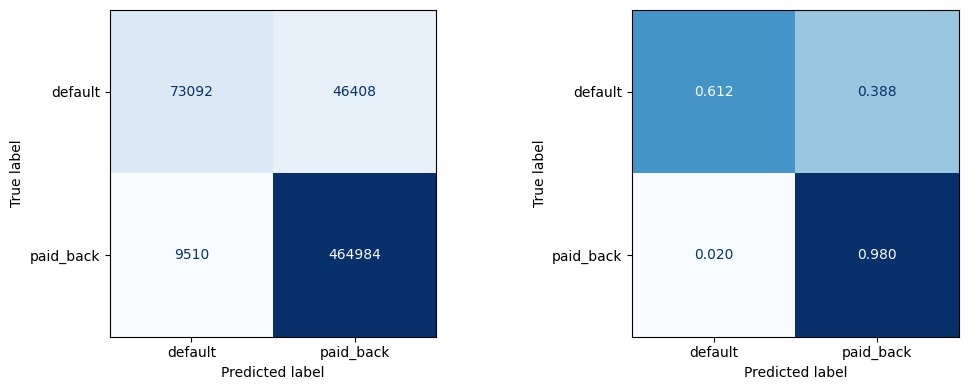

In [121]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                       display_labels=['default', 'paid_back']).plot(
    ax=ax[0], cmap='Blues', colorbar=False)
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred, normalize='true'),
                       display_labels=['default', 'paid_back']).plot(
    ax=ax[1], cmap='Blues', colorbar=False, values_format='.3f')
plt.tight_layout()
plt.show()


## 6.6 Subpopulation performance


In [122]:
from sklearn.metrics import precision_score, recall_score


def per_group_metrics(y_true, y_pred, group):
    df = pd.DataFrame({'y': np.asarray(y_true), 'p': np.asarray(y_pred)})
    if isinstance(group, pd.DataFrame):
        df = pd.concat([df.reset_index(drop=True), group.reset_index(drop=True)], axis=1)
        cols = list(group.columns)
    else:
        df['__g'] = np.asarray(group)
        cols = ['__g']

    def _row(g):
        yt, yp = g['y'].values, g['p'].values
        pos, neg = (yt == 1).sum(), (yt == 0).sum()
        return pd.Series({
            'count': len(g),
            'base_rate': pos / len(g) if len(g) else 0,
            'selection_rate': yp.mean(),
            'accuracy': (yp == yt).mean(),
            'precision': precision_score(yt, yp, zero_division=0),
            'recall': recall_score(yt, yp, zero_division=0),
            'fpr': ((yp == 1) & (yt == 0)).sum() / max(neg, 1),
            'fnr': ((yp == 0) & (yt == 1)).sum() / max(pos, 1),
        })

    out = df.groupby(cols, observed=True).apply(_row, include_groups=False)
    if cols == ['__g']:
        out.index.name = group.name if hasattr(group, 'name') else 'group'
    return out


def disparity_summary(bg):
    cols = [c for c in bg.columns if c != 'count']
    gap = (bg[cols].max() - bg[cols].min()).round(4)
    ratio = (bg[cols].min() / bg[cols].max().replace(0, np.nan)).round(4)
    return pd.DataFrame({'gap': gap, 'ratio': ratio})


gender = pd.Series(
    np.where(df_train['gender_Male'] == 1, 'Male',
    np.where(df_train['gender_Other'] == 1, 'Other', 'Female')),
    index=df_train.index, name='gender')
marital = pd.Series(
    np.where(df_train['marital_status_Married'] == 1, 'Married',
    np.where(df_train['marital_status_Single'] == 1, 'Single',
    np.where(df_train['marital_status_Widowed'] == 1, 'Widowed', 'Divorced'))),
    index=df_train.index, name='marital_status')
education = df_train['education_level'].map(
    {0: 'Other', 1: 'High School', 2: "Bachelor's", 3: "Master's", 4: 'PhD'}
).rename('education_level')

y_pred_bin = (oof_preds >= 0.5).astype(int)

print(gender.value_counts())
print(marital.value_counts())
print(education.value_counts())


gender
Female    306175
Male      284091
Other       3728
Name: count, dtype: int64
marital_status
Single      288843
Married     277239
Divorced     21312
Widowed       6600
Name: count, dtype: int64
education_level
Bachelor's     279606
High School    183592
Master's        93097
Other           26677
PhD             11022
Name: count, dtype: int64


In [123]:
bg_g = per_group_metrics(y.values, y_pred_bin, gender)
print(bg_g.round(4))
print(disparity_summary(bg_g))


           count  base_rate  selection_rate  accuracy  precision  recall  \
gender                                                                     
Female  306175.0     0.8017          0.8622    0.9073     0.9111  0.9799   
Male    284091.0     0.7958          0.8596    0.9044     0.9073  0.9801   
Other     3728.0     0.7953          0.8616    0.8983     0.9026  0.9777   

           fpr     fnr  
gender                  
Female  0.3863  0.0201  
Male    0.3902  0.0199  
Other   0.4102  0.0223  
                   gap   ratio
base_rate       0.0064  0.9920
selection_rate  0.0026  0.9970
accuracy        0.0089  0.9902
precision       0.0086  0.9906
recall          0.0023  0.9976
fpr             0.0239  0.9418
fnr             0.0023  0.8954


In [124]:
bg_m = per_group_metrics(y.values, y_pred_bin, marital)
print(bg_m.round(4))
print(disparity_summary(bg_m))


                   count  base_rate  selection_rate  accuracy  precision  \
marital_status                                                             
Divorced         21312.0     0.7966          0.8606    0.9056     0.9080   
Married         277239.0     0.7991          0.8628    0.9048     0.9079   
Single          288843.0     0.7989          0.8593    0.9069     0.9107   
Widowed           6600.0     0.7898          0.8561    0.9041     0.9053   

                recall     fpr     fnr  
marital_status                          
Divorced        0.9809  0.3892  0.0191  
Married         0.9803  0.3955  0.0197  
Single          0.9795  0.3815  0.0205  
Widowed         0.9812  0.3857  0.0188  
                   gap   ratio
base_rate       0.0093  0.9884
selection_rate  0.0068  0.9922
accuracy        0.0028  0.9969
precision       0.0054  0.9941
recall          0.0017  0.9983
fpr             0.0141  0.9645
fnr             0.0017  0.9192


In [125]:
bg_e = per_group_metrics(y.values, y_pred_bin, education)
edu_order = ['Other', 'High School', "Bachelor's", "Master's", 'PhD']
bg_e = bg_e.reindex([e for e in edu_order if e in bg_e.index])
print(bg_e.round(4))
print(disparity_summary(bg_e))


                    count  base_rate  selection_rate  accuracy  precision  \
education_level                                                             
Other             26677.0     0.8028          0.8658    0.9044     0.9084   
High School      183592.0     0.8097          0.8677    0.9097     0.9145   
Bachelor's       279606.0     0.7889          0.8541    0.9031     0.9051   
Master's          93097.0     0.8023          0.8647    0.9057     0.9094   
PhD               11022.0     0.8301          0.8801    0.9163     0.9240   

                 recall     fpr     fnr  
education_level                          
Other            0.9797  0.4020  0.0203  
High School      0.9800  0.3896  0.0200  
Bachelor's       0.9799  0.3838  0.0201  
Master's         0.9801  0.3962  0.0199  
PhD              0.9797  0.3935  0.0203  
                   gap   ratio
base_rate       0.0412  0.9504
selection_rate  0.0260  0.9705
accuracy        0.0131  0.9857
precision       0.0189  0.9796
recall     

In [126]:
def show_intersection(name, sens):
    bg = per_group_metrics(y.values, y_pred_bin, sens)
    print(name)
    print(bg.round(4).sort_values('selection_rate', ascending=False))
    filt = bg[bg['count'] >= 500]
    print('n>=500')
    print(disparity_summary(filt))
    return bg

bg_gm = show_intersection('gender x marital',
    pd.DataFrame({'gender': gender.values, 'marital_status': marital.values}))
bg_ge = show_intersection('gender x education',
    pd.DataFrame({'gender': gender.values, 'education_level': education.values}))
bg_me = show_intersection('marital x education',
    pd.DataFrame({'marital_status': marital.values, 'education_level': education.values}))


gender x marital
                          count  base_rate  selection_rate  accuracy  \
gender marital_status                                                  
Other  Divorced           124.0     0.8065          0.8952    0.8952   
       Widowed             31.0     0.8387          0.8710    0.9677   
       Single            1825.0     0.7989          0.8679    0.8981   
Female Married         143010.0     0.8025          0.8643    0.9063   
       Divorced         10811.0     0.7982          0.8621    0.9052   
Male   Married         132481.0     0.7956          0.8614    0.9033   
Female Single          148908.0     0.8015          0.8603    0.9084   
Male   Divorced         10377.0     0.7949          0.8586    0.9062   
       Single          138110.0     0.7961          0.8580    0.9055   
       Widowed           3123.0     0.7880          0.8575    0.9023   
Female Widowed           3446.0     0.7911          0.8546    0.9051   
Other  Married           1748.0     0.7900     

In [127]:
intersections = {
    'gender x marital': bg_gm,
    'gender x education': bg_ge,
    'marital x education': bg_me,
}
for name, bg in intersections.items():
    bg_f = bg[bg['count'] >= 500].sort_values('selection_rate', ascending=False)
    ratio = bg_f['selection_rate'].min() / bg_f['selection_rate'].max()
    print(name, round(ratio, 4), bg_f.iloc[0].name, bg_f.iloc[-1].name)

for name, bg in intersections.items():
    bg_f = bg[bg['count'] >= 500]
    corr = bg_f[['base_rate', 'selection_rate']].corr().iloc[0, 1]
    print(name, 'corr', round(corr, 3))


gender x marital 0.9821 ('Other', 'Single') ('Other', 'Married')
gender x education 0.9431 ('Female', 'PhD') ('Other', "Master's")
marital x education 0.9585 ('Married', 'PhD') ('Widowed', "Bachelor's")
gender x marital corr 0.756
gender x education corr 0.978
marital x education corr 0.925


In [128]:
def fairness_plot(metric_col, agg_value, title, color='#4C72B0'):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, (name, bg) in zip(axes, [('Gender', bg_g), ('Marital', bg_m), ('Education', bg_e)]):
        ax.bar(range(len(bg)), bg[metric_col], color=color, edgecolor='black', linewidth=0.5)
        ax.set_xticks(range(len(bg)))
        ax.set_xticklabels(bg.index, rotation=20, ha='right')
        ax.axhline(agg_value, color='red', linestyle='--', alpha=0.6)
        ax.set_title(name)
        spread = bg[metric_col].max() - bg[metric_col].min()
        pad = max(spread * 0.5, 0.002)
        ax.set_ylim(bg[metric_col].min() - pad, bg[metric_col].max() + pad)
        ratio = bg[metric_col].min() / bg[metric_col].max()
        ax.text(0.02, 0.95, f'ratio={ratio:.3f}', transform=ax.transAxes,
                fontsize=9, verticalalignment='top')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


agg_sr = float(y_pred_bin.mean())
agg_recall = float(((y_pred_bin == 1) & (y.values == 1)).sum() / (y.values == 1).sum())
agg_fpr = float(((y_pred_bin == 1) & (y.values == 0)).sum() / (y.values == 0).sum())
agg_fnr = float(((y_pred_bin == 0) & (y.values == 1)).sum() / (y.values == 1).sum())


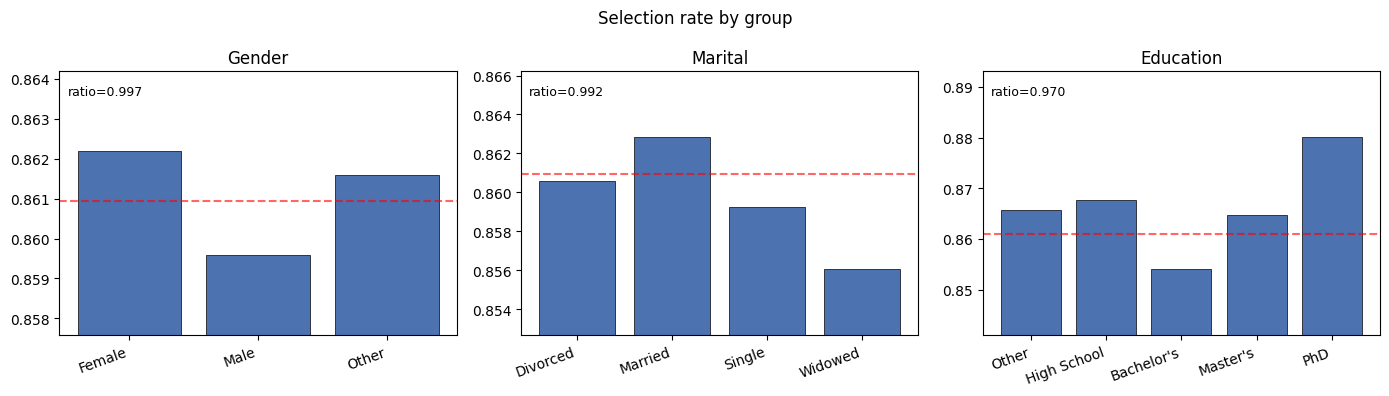

In [129]:
fairness_plot('selection_rate', agg_sr, 'Selection rate by group')


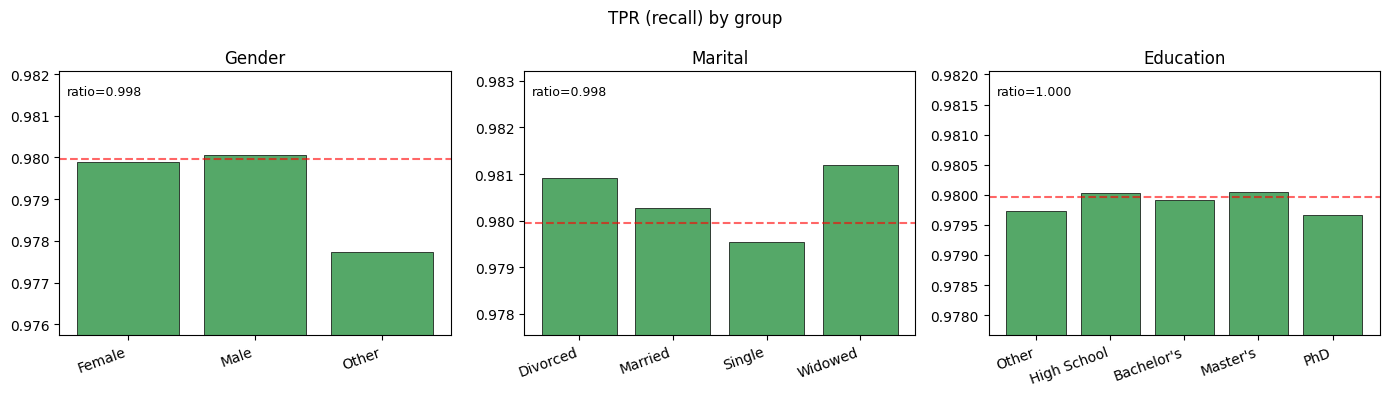

In [130]:
fairness_plot('recall', agg_recall, 'TPR (recall) by group', color='#55A868')


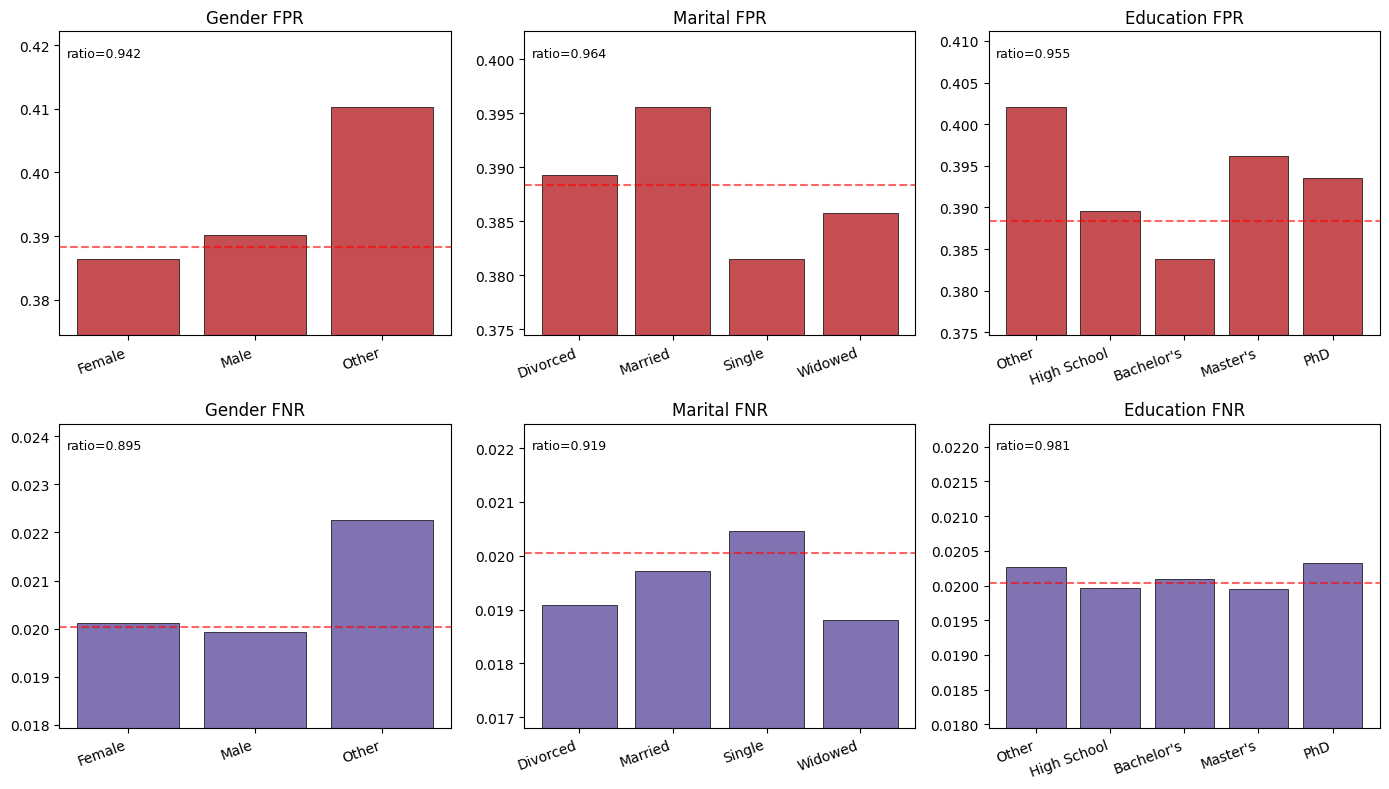

In [131]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
panels = [('fpr', 'FPR', agg_fpr, '#C44E52'), ('fnr', 'FNR', agg_fnr, '#8172B2')]
for r, (col, label, agg, color) in enumerate(panels):
    for c, (name, bg) in enumerate([('Gender', bg_g), ('Marital', bg_m), ('Education', bg_e)]):
        ax = axes[r, c]
        ax.bar(range(len(bg)), bg[col], color=color, edgecolor='black', linewidth=0.5)
        ax.set_xticks(range(len(bg)))
        ax.set_xticklabels(bg.index, rotation=20, ha='right')
        ax.axhline(agg, color='red', linestyle='--', alpha=0.6)
        ax.set_title(f'{name} {label}')
        spread = bg[col].max() - bg[col].min()
        pad = max(spread * 0.5, 0.002)
        ax.set_ylim(bg[col].min() - pad, bg[col].max() + pad)
        ratio = bg[col].min() / bg[col].max()
        ax.text(0.02, 0.95, f'ratio={ratio:.3f}', transform=ax.transAxes,
                fontsize=9, verticalalignment='top')
plt.tight_layout()
plt.show()


## 7. Audit


In [132]:
!pip install shap lime

In [133]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

fold_lgbs, fold_cats, fold_scalers = [], [], []

skf_audit = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

for fold, (train_idx, _) in enumerate(skf_audit.split(X, y), 1):
    X_tr = X.iloc[train_idx]
    y_tr = y.iloc[train_idx]
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    m_lgb = LGBMClassifier(**lgbm_params)
    m_cat = CatBoostClassifier(**cat_params)
    m_lgb.fit(X_tr_s, y_tr)
    m_cat.fit(X_tr_s, y_tr)
    fold_lgbs.append(m_lgb)
    fold_cats.append(m_cat)
    fold_scalers.append(scaler)
    print(f"fold {fold}/{n_splits}")


def predict_proba_ensemble(X_input):
    if not isinstance(X_input, pd.DataFrame):
        X_input = pd.DataFrame(X_input, columns=X.columns)
    p1 = np.zeros(len(X_input))
    for sc, m_lgb, m_cat in zip(fold_scalers, fold_lgbs, fold_cats):
        X_s = sc.transform(X_input)
        lgb_p = m_lgb.predict_proba(X_s)[:, 1]
        cat_p = m_cat.predict_proba(X_s)[:, 1]
        p1 += np.sqrt(0.70 * lgb_p**2 + 0.30 * cat_p**2) / n_splits
    return np.column_stack([1.0 - p1, p1])


fold 1/10
fold 2/10
fold 3/10
fold 4/10
fold 5/10
fold 6/10
fold 7/10
fold 8/10
fold 9/10
fold 10/10


### 7.1 Global SHAP


/var/folders/vb/cb7qfh896f3dl00py8kjsvp80000gn/T/ipykernel_35996/3510614087.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_lgb, X_sample, show=True)


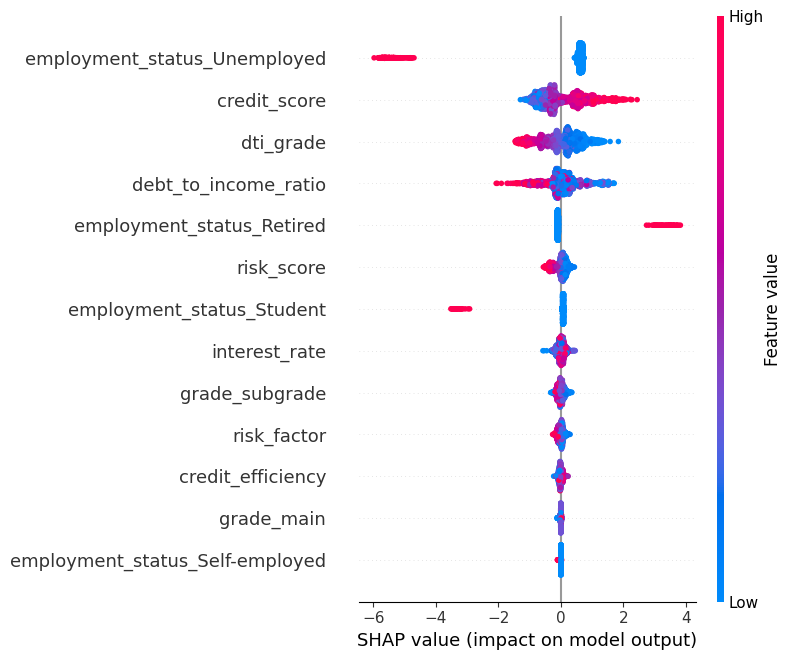

/var/folders/vb/cb7qfh896f3dl00py8kjsvp80000gn/T/ipykernel_35996/3510614087.py:26: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_cat, X_sample, show=True)


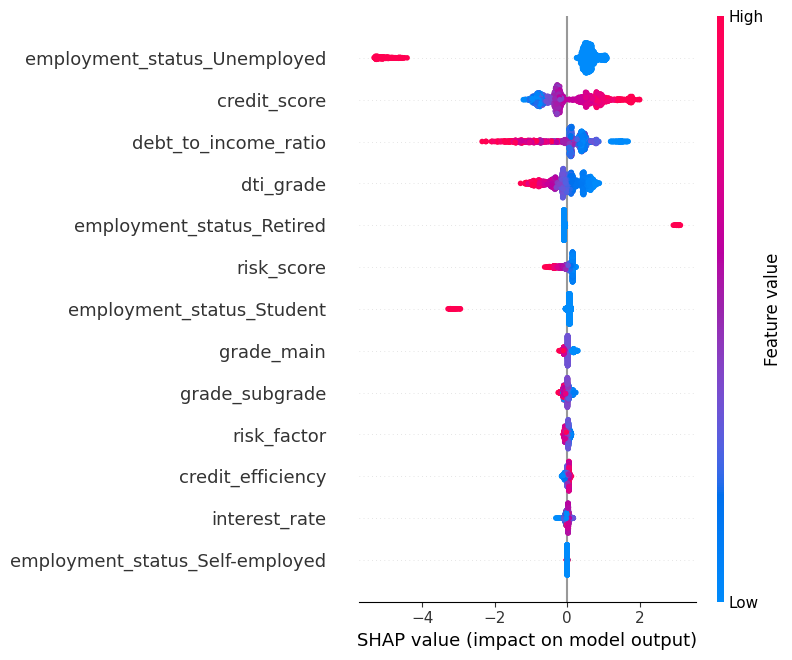

In [134]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning,
    message=".*LightGBM binary classifier with TreeExplainer.*")
warnings.filterwarnings("ignore", message=".*IProgress not found.*")

import shap

sample_idx = np.random.RandomState(42).choice(len(X), size=2000, replace=False)
X_sample = X.iloc[sample_idx].reset_index(drop=True)

sv_lgb = np.zeros((len(X_sample), X.shape[1]))
sv_cat = np.zeros((len(X_sample), X.shape[1]))

for sc, m_lgb, m_cat in zip(fold_scalers, fold_lgbs, fold_cats):
    X_s = sc.transform(X_sample)
    s_lgb = shap.TreeExplainer(m_lgb).shap_values(X_s)
    if isinstance(s_lgb, list):
        s_lgb = s_lgb[1]
    sv_lgb += s_lgb / n_splits
    s_cat = shap.TreeExplainer(m_cat).shap_values(X_s)
    if isinstance(s_cat, list):
        s_cat = s_cat[1]
    sv_cat += s_cat / n_splits

shap.summary_plot(sv_lgb, X_sample, show=True)
shap.summary_plot(sv_cat, X_sample, show=True)


/var/folders/vb/cb7qfh896f3dl00py8kjsvp80000gn/T/ipykernel_35996/591757482.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_lgb, X_sample, plot_type='bar', show=True)


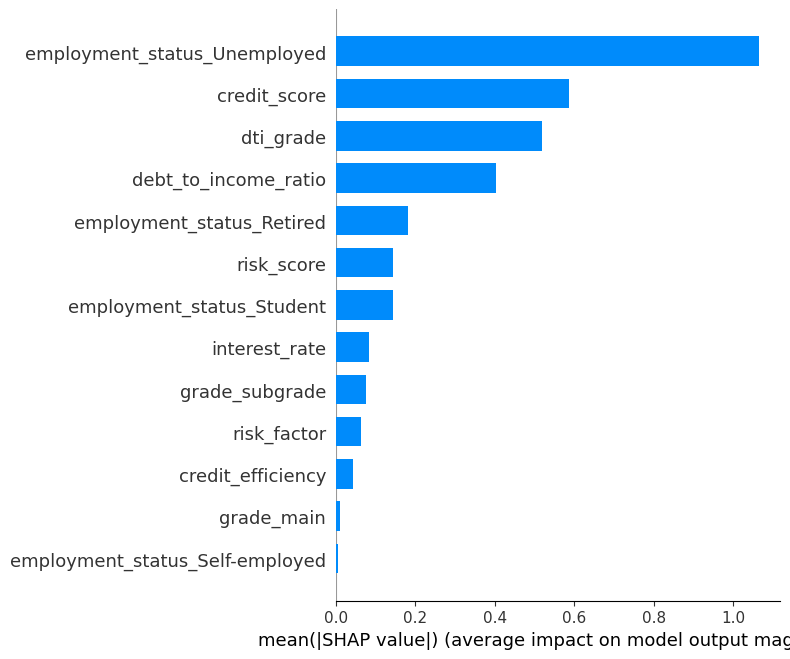

/var/folders/vb/cb7qfh896f3dl00py8kjsvp80000gn/T/ipykernel_35996/591757482.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_cat, X_sample, plot_type='bar', show=True)


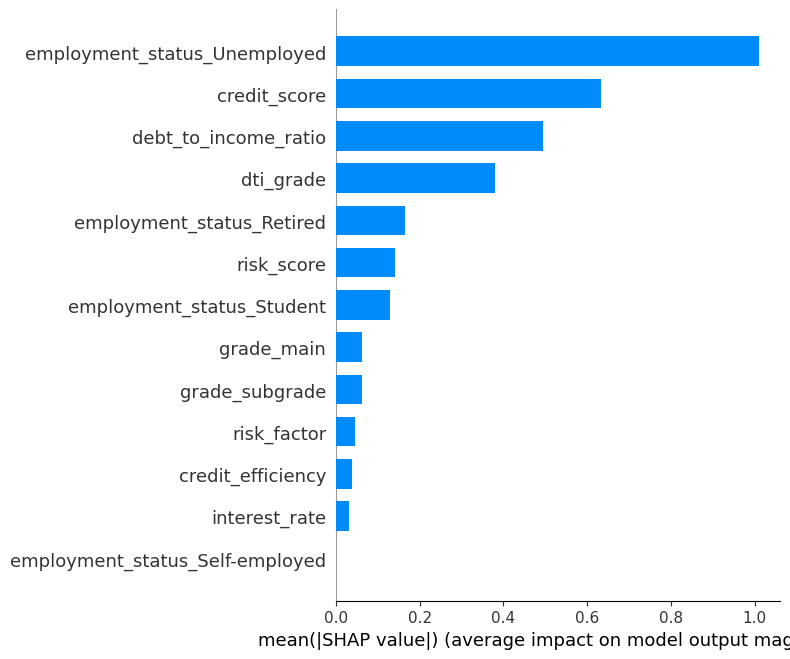

In [135]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning,
    message=".*LightGBM binary classifier with TreeExplainer.*")

shap.summary_plot(sv_lgb, X_sample, plot_type='bar', show=True)
shap.summary_plot(sv_cat, X_sample, plot_type='bar', show=True)


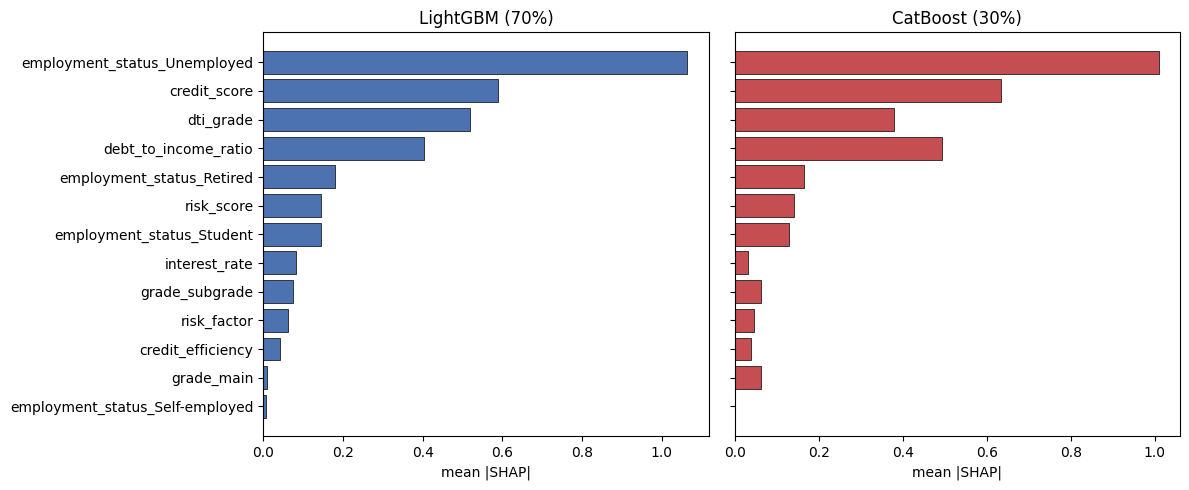

                            feature    lgbm     cat
0      employment_status_Unemployed  1.0647  1.0096
1                      credit_score  0.5881  0.6333
2                         dti_grade  0.5180  0.3801
3              debt_to_income_ratio  0.4024  0.4941
4         employment_status_Retired  0.1807  0.1642
5                        risk_score  0.1451  0.1418
6         employment_status_Student  0.1444  0.1288
7                     interest_rate  0.0833  0.0309
8                    grade_subgrade  0.0755  0.0619
9                       risk_factor  0.0630  0.0467
10                credit_efficiency  0.0427  0.0392
11                       grade_main  0.0103  0.0633
12  employment_status_Self-employed  0.0059  0.0014


In [136]:
mi_lgb = np.abs(sv_lgb).mean(axis=0)
mi_cat = np.abs(sv_cat).mean(axis=0)
feat_names = list(X.columns)
order = np.argsort(mi_lgb)
sorted_feats = [feat_names[i] for i in order]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
axes[0].barh(sorted_feats, mi_lgb[order], color='#4C72B0', edgecolor='black', linewidth=0.5)
axes[0].set_title('LightGBM (70%)')
axes[0].set_xlabel('mean |SHAP|')
axes[1].barh(sorted_feats, mi_cat[order], color='#C44E52', edgecolor='black', linewidth=0.5)
axes[1].set_title('CatBoost (30%)')
axes[1].set_xlabel('mean |SHAP|')
plt.tight_layout()
plt.show()

ranking = pd.DataFrame({
    'feature': feat_names,
    'lgbm': mi_lgb.round(4),
    'cat':  mi_cat.round(4),
}).sort_values('lgbm', ascending=False).reset_index(drop=True)
print(ranking)


### 7.2 SHAP dependence on flagged features


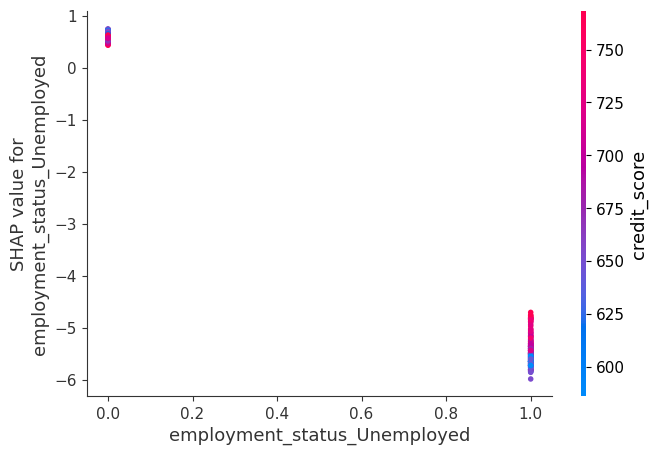

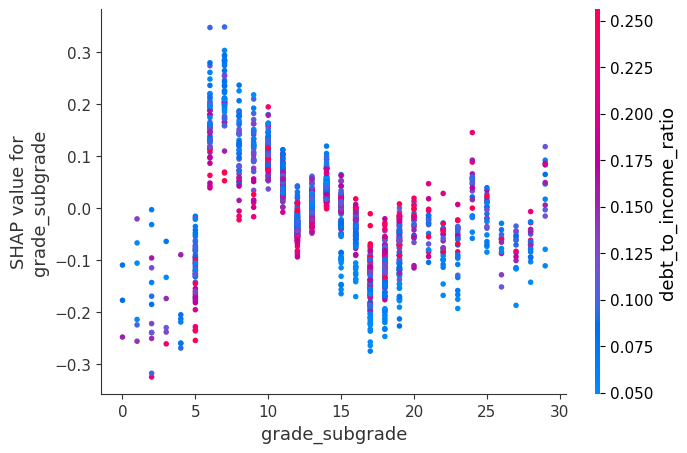

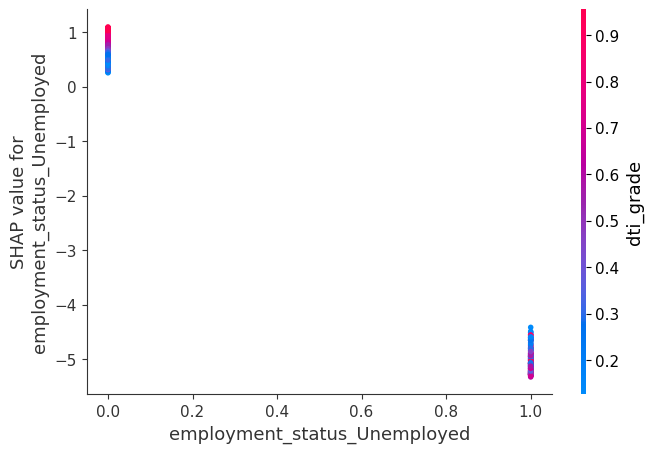

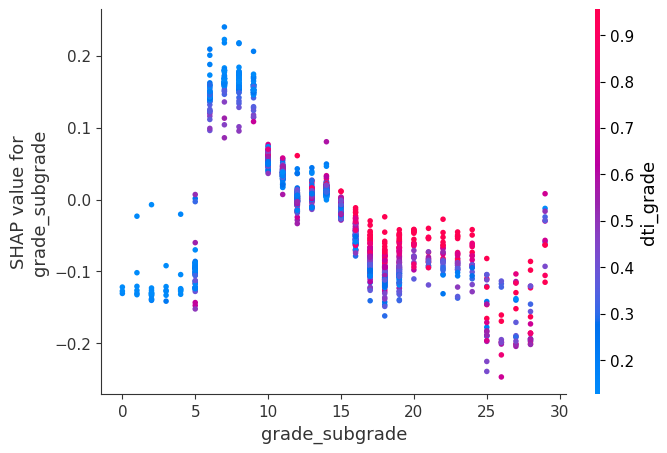

In [137]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning,
    message=".*LightGBM binary classifier with TreeExplainer.*")

shap.dependence_plot('employment_status_Unemployed', sv_lgb, X_sample, show=True)
shap.dependence_plot('grade_subgrade', sv_lgb, X_sample, show=True)
shap.dependence_plot('employment_status_Unemployed', sv_cat, X_sample, show=True)
shap.dependence_plot('grade_subgrade', sv_cat, X_sample, show=True)


### 7.3 LIME


In [138]:
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

import lime
import lime.lime_tabular

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X.values,
    feature_names=list(X.columns),
    class_names=['default', 'paid_back'],
    mode='classification',
    discretize_continuous=True,
    random_state=42,
)

idx_paid    = int(np.argmax(oof_preds))
idx_default = int(np.argmin(oof_preds))
idx_border  = int(np.argmin(np.abs(oof_preds - 0.5)))

for label, idx in [('paid', idx_paid), ('default', idx_default), ('border', idx_border)]:
    print(label, idx, round(oof_preds[idx], 3), int(y.iloc[idx]))
    exp = lime_explainer.explain_instance(
        X.iloc[idx].values, predict_proba_ensemble, num_features=10)
    for feat, w in exp.as_list():
        print(' ', round(w, 4), feat)


paid 231848 1.0 1
  0.743 employment_status_Unemployed <= 0.00
  0.4414 employment_status_Student <= 0.00
  0.121 employment_status_Retired > 0.00
  0.1071 credit_score > 719.00
  0.0742 dti_grade <= 0.22
  0.0506 debt_to_income_ratio <= 0.07
  0.0156 risk_score <= 0.87
  0.0088 credit_efficiency > 58.88
  0.0066 employment_status_Self-employed <= 0.00
  0.0055 risk_factor <= 135.12
default 549670 0.0 0
  -0.7592 employment_status_Unemployed > 0.00
  0.4733 employment_status_Student <= 0.00
  -0.1311 employment_status_Retired <= 0.00
  -0.1073 debt_to_income_ratio > 0.16
  -0.0999 dti_grade > 0.53
  -0.099 credit_score <= 646.00
  -0.0279 risk_score > 1.92
  -0.0149 risk_factor > 233.89
  -0.0088 credit_efficiency <= 44.77
  0.0065 2.00 < grade_main <= 3.00
border 182290 0.5 0
  0.7491 employment_status_Unemployed <= 0.00
  0.4631 employment_status_Student <= 0.00
  -0.1302 employment_status_Retired <= 0.00
  -0.109 debt_to_income_ratio > 0.16
  -0.1072 dti_grade > 0.53
  -0.0997 credi

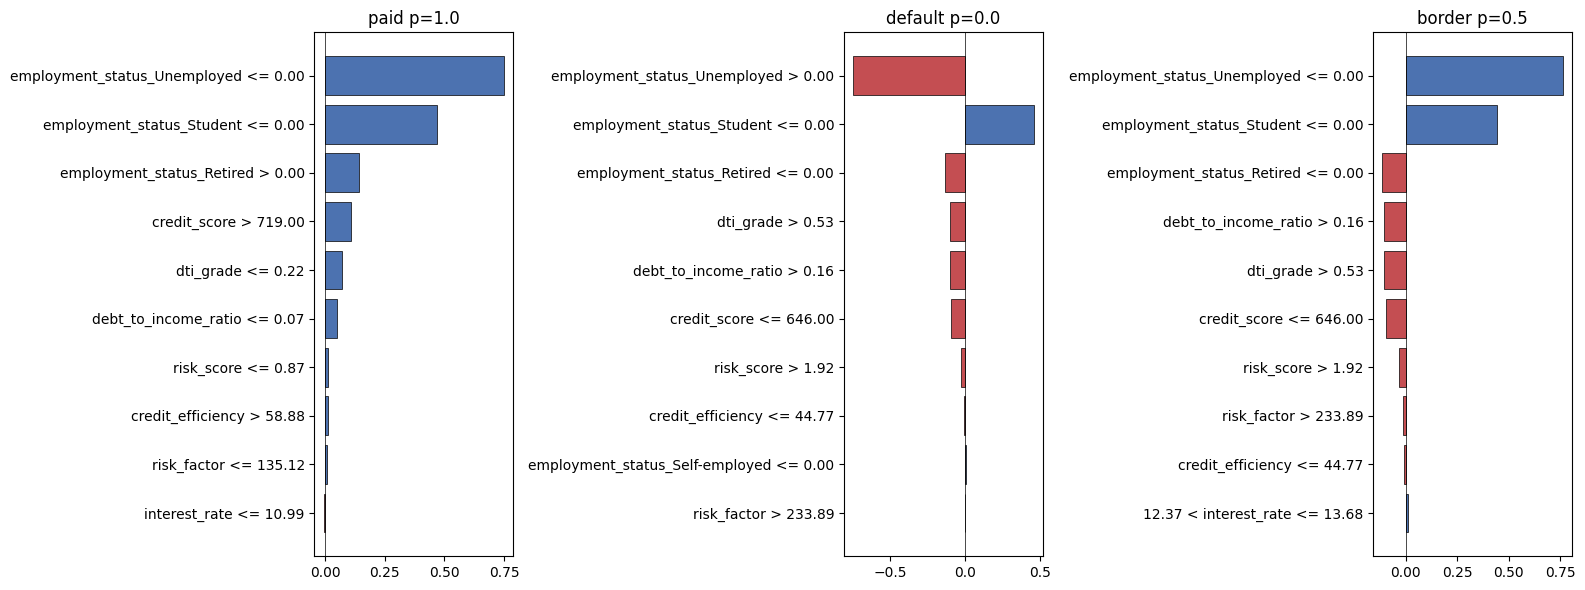

In [139]:
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

cases = [('paid p=1.0', idx_paid), ('default p=0.0', idx_default), ('border p=0.5', idx_border)]
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, (label, idx) in zip(axes, cases):
    exp = lime_explainer.explain_instance(
        X.iloc[idx].values, predict_proba_ensemble, num_features=10)
    items = exp.as_list()
    feats = [f for f, w in items][::-1]
    weights = [w for f, w in items][::-1]
    colors = ['#4C72B0' if w >= 0 else '#C44E52' for w in weights]
    ax.barh(feats, weights, color=colors, edgecolor='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_title(label)
plt.tight_layout()
plt.show()


## 7.4 Stability and robustness


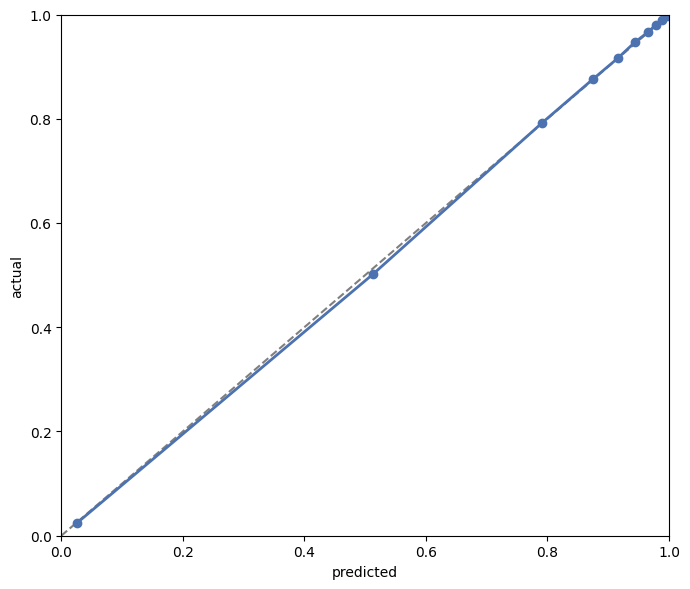

brier 0.0716
baseline 0.1607


In [140]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_true, prob_pred = calibration_curve(y, oof_preds, n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.plot(prob_pred, prob_true, 'o-', color='#4C72B0', linewidth=2)
ax.set_xlabel('predicted')
ax.set_ylabel('actual')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print('brier', round(brier_score_loss(y, oof_preds), 4))
print('baseline', round(brier_score_loss(y, np.full_like(oof_preds, y.mean(), dtype=float)), 4))


mean dp 0.0285
median dp 0.0103
p95 dp 0.1224
flip rate 0.0227


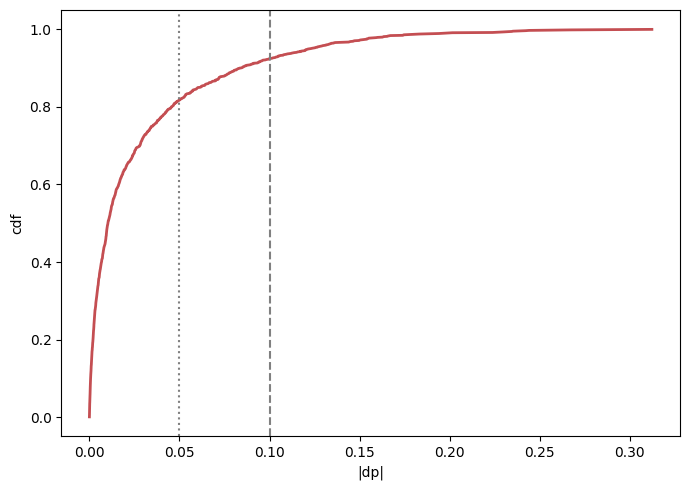

In [141]:
np.random.seed(42)
continuous_cols = [c for c in X.columns if not c.startswith('employment_status_')]

n_sample, n_trials = 500, 3
sample_idx = np.random.choice(len(X), size=n_sample, replace=False)
X_clean = X.iloc[sample_idx].copy().reset_index(drop=True)
p_clean = predict_proba_ensemble(X_clean.values)[:, 1]

feature_std = X[continuous_cols].std(axis=0).values
shifts, flips = [], []
for _ in range(n_trials):
    X_p = X_clean.copy()
    noise = np.random.randn(n_sample, len(continuous_cols)) * feature_std * 0.05
    X_p[continuous_cols] = X_clean[continuous_cols].values + noise
    p_p = predict_proba_ensemble(X_p.values)[:, 1]
    shifts.append(np.abs(p_clean - p_p))
    flips.append((p_clean >= 0.5) != (p_p >= 0.5))

shifts = np.concatenate(shifts)
flip_rate = np.concatenate(flips).mean()
print('mean dp', round(shifts.mean(), 4))
print('median dp', round(np.median(shifts), 4))
print('p95 dp', round(np.percentile(shifts, 95), 4))
print('flip rate', round(flip_rate, 4))

fig, ax = plt.subplots(figsize=(7, 5))
sorted_shifts = np.sort(shifts)
cdf = np.arange(1, len(sorted_shifts) + 1) / len(sorted_shifts)
ax.plot(sorted_shifts, cdf, color='#C44E52', linewidth=2)
ax.axvline(0.05, color='gray', linestyle=':')
ax.axvline(0.10, color='gray', linestyle='--')
ax.set_xlabel('|dp|')
ax.set_ylabel('cdf')
plt.tight_layout()
plt.show()
